In [1]:
import os
if os.getcwd().endswith('scripts'):
    os.chdir('..')
print(f"Current working directory: {os.getcwd()}")

Current working directory: c:\Users\YuMeow\WorkSpace\35-HuaweiCrowdSimulation\HuaweiCrowdSimulationCode


In [ ]:
from pathlib import Path

tmp = []
for path in Path('./data/SDD/annotations').glob('**/reference.jpg'):
    try:
        map_path = next(iter(path.parent.glob('*-map.png')))
    except StopIteration:
        continue
    
    image = Image.open(path)
    map = Image.open(map_path)

    # 将 map 的宽高调整为 image 的宽高
    map = map.resize(image.size, Image.LANCZOS)
    map.save(map_path.parent / 'map.png')
    print(f'Saved {map_path}')
    # tmp.append(int(map_path.name.split('-')[0]))
sorted(tmp)

Saved ..\data\SDD\annotations\bookstore\video0\0-map.png
Saved ..\data\SDD\annotations\bookstore\video1\1-map.png
Saved ..\data\SDD\annotations\bookstore\video2\2-map.png
Saved ..\data\SDD\annotations\bookstore\video3\3-map.png
Saved ..\data\SDD\annotations\bookstore\video4\4-map.png
Saved ..\data\SDD\annotations\bookstore\video5\5-map.png
Saved ..\data\SDD\annotations\bookstore\video6\6-map.png
Saved ..\data\SDD\annotations\coupa\video0\7-map.png
Saved ..\data\SDD\annotations\coupa\video1\8-map.png
Saved ..\data\SDD\annotations\coupa\video2\9-map.png
Saved ..\data\SDD\annotations\coupa\video3\10-map.png
Saved ..\data\SDD\annotations\deathCircle\video0\11-map.png
Saved ..\data\SDD\annotations\deathCircle\video1\12-map.png
Saved ..\data\SDD\annotations\deathCircle\video2\13-map.png
Saved ..\data\SDD\annotations\deathCircle\video3\14-map.png
Saved ..\data\SDD\annotations\deathCircle\video4\15-map.png
Saved ..\data\SDD\annotations\gates\video0\16-map.png
Saved ..\data\SDD\annotations\gate

[]

(np.float64(0.0),
 np.float64(9.992435703479575),
 np.float64(-3.831167103483155e-16),
 np.float64(8.154311649016647))

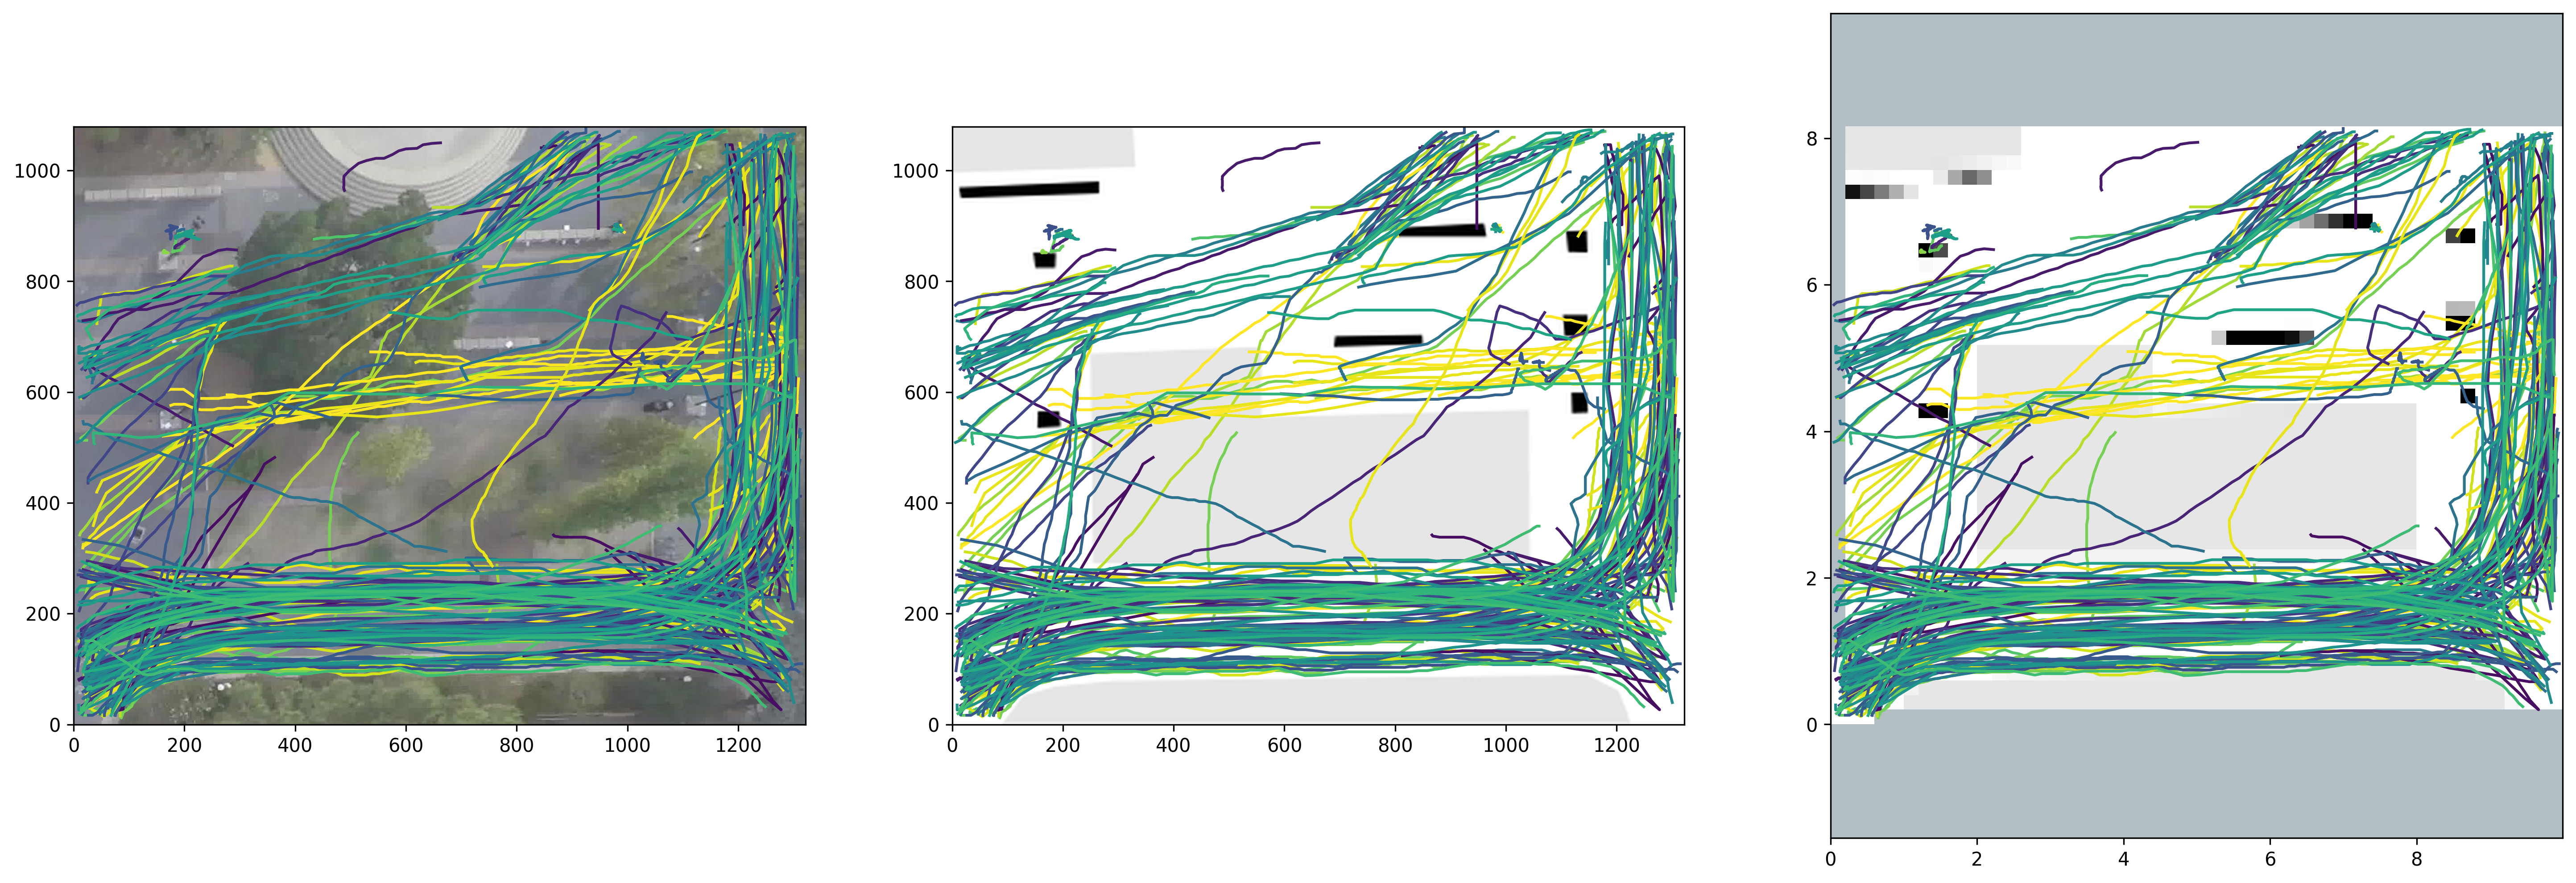

In [2]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
from src.dataset import BaseDataset, SDDDataset
import matplotlib.pyplot as plt
from src.utils.homography import calc_homography_mat, affine_transformation, image_to_world
from PIL import Image

data_path = Path('./data/SDD/annotations/bookstore/video3/annotations.txt')

## 读取数据
df_data = pd.read_csv(
    data_path,
    sep=" ",
    names=[
        "id", "xmin", "ymin", "xmax", "ymax",
        "frame", "lost", "occluded", "generated", "label",
    ],
    usecols=["id", "xmin", "ymin", "xmax", "ymax", "frame", "label"],
)
df_data["x"] = (df_data["xmin"] + df_data["xmax"]) / 2
df_data["y"] = (df_data["ymin"] + df_data["ymax"]) / 2
df_data = df_data.rename(columns={"frame": "f", "label": "type"})
df_data['type'] = df_data['type'].replace({
    'Pedestrian': 'pedestrian',
    'Skater': 'vehicle',
    'Biker': 'vehicle',
    'Cart': 'vehicle',
    'Car': 'vehicle',
    'Bus': 'vehicle',
})
df_data = df_data[['f', 'id', 'x', 'y', 'type']]

## 仿射变换
# H = cls.get_homography_mat(mat_name=data_path.parent.parent.name)
# df_data[['x', 'y']] = affine_transformation(df_data[['x', 'y']].values, H)
image0 = np.array(Image.open(data_path.parent / 'reference.jpg'))
h, w, _ = image0.shape
df_data['y'] = h - df_data['y']
ratio = 10 / max(h, w)
H = calc_homography_mat(
    np.array([[0, 0], [w, 0], [0, h], [w, h]]),
    np.array([[0, 0], [w, 0], [0, h], [w, h]]) * ratio,
)
df_data[['x', 'y']] = affine_transformation(df_data[['x', 'y']].values, H)

## 数据重采样
df_data = SDDDataset.resample_dataframe(df_data, raw_fps=SDDDataset.raw_fps, target_fps=2.5)

df_data[['raw_x', 'raw_y']] = affine_transformation(df_data[['x', 'y']].values, np.linalg.inv(H))

## 读取地图
image = np.array(Image.open(data_path.parent / f"map.png").convert('L'))  # (H, W)  第一维向下，第二维向右
_image = image[::-1].T # 转置，使得第一维向右，第二维向下，与 df_data 中的坐标系对齐
map, xmin, xmax, ymin, ymax = image_to_world(_image, H, dot_per_meter=5)  # 第一维向右，第二维向上，即 xy 坐标

## 可视化
fig, axes = plt.subplots(1, 3, figsize=(24, 8), dpi=300)
cmap = plt.get_cmap('viridis')

image0 = np.array(Image.open(data_path.parent / 'reference.jpg'))
h, w  = image0.shape[:2]
axes[0].imshow(image0, extent=[0, w, 0, h], alpha=1.0)
for pid, group in df_data.groupby('id'):
    axes[0].plot(group['raw_x'], group['raw_y'], color=cmap(group['f'].max() / df_data['f'].max()))
# axes[0].imshow(image0, extent=[0, w, 0, h], alpha=0.5, zorder=999999)

h, w = image.shape
axes[1].imshow(image, extent=[0, w, 0, h], alpha=1.0, cmap='gray_r')
for pid, group in df_data.groupby('id'):
    axes[1].plot(group['raw_x'], group['raw_y'], color=cmap(group['f'].max() / df_data['f'].max()))

axes[2].imshow(map, origin='lower', extent=(xmin, xmax, ymin, ymax), cmap='gray_r')  # 第一维向右、第二维向上：需要设置 origin='lower'
for pid, group in df_data.groupby('id'):
    axes[2].plot(group['x'], group['y'], color=cmap(group['f'].max() / df_data['f'].max()))
axes[2].set_facecolor('#b2bec3')
axes[2].axis('equal')

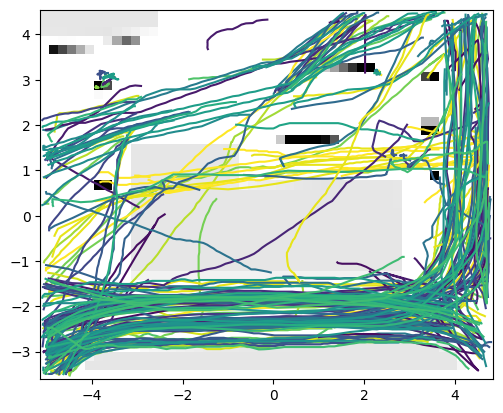

In [3]:
from src.dataset import SDDDataset
from argparse import Namespace
dataset = SDDDataset.load_data(Namespace(
    cache_dataset=False,
    fps=2.5,
    dot_per_meter=5,
    hist_step=8,
    pred_step=1,
    roll_step=12,
    skip_step=1,
), 'data/SDD/annotations/bookstore/video3/annotations.txt')
plt.imshow(dataset.map_data.map, extent=(dataset.map_data.xmin, dataset.map_data.xmax, dataset.map_data.ymin, dataset.map_data.ymax), origin='lower', cmap='gray_r')
for pid, group in dataset.df_data.groupby('id'):
    plt.plot(group['x'], group['y'], color=cmap(group['f'].max() / dataset.df_data['f'].max()))